<a href="https://colab.research.google.com/github/henriquecrispim/economic-web-scraping-automation/blob/main/economic_web_scraping_automation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Enviando requisição HTTP para: https://www.infomoney.com.br/mercados/...
[SUCESSO] Página acessada. Iniciando parsing do HTML...

[SUCESSO] Total de 11 notícias únicas extraídas do mercado:
         Data_Extracao                                           Headline  \
0  2026-07-01 01:51:54  “Sal é o novo petróleo”: como as baterias de s...   
1  2026-07-01 01:51:54  Principal questão do mercado não é mais identi...   
2  2026-07-01 01:51:54  A gente não vende ilusão mas tem oportunidade,...   
3  2026-07-01 01:51:54  Pane no sistema? Big Techs têm reviravolta e p...   
4  2026-07-01 01:51:54  4 ações sobem mais de 30% e 13 caem mais de 20...   

                                                Link  
0  https://www.infomoney.com.br/mercados/sal-e-o-...  
1  https://www.infomoney.com.br/mercados/principa...  
2  https://www.infomoney.com.br/mercados/automaca...  
3  https://www.infomoney.com.br/mercados/pane-no-...  
4  https://www.infomoney.com.br/mercados/11-acoes...  

[ARQUIVO GERADO]

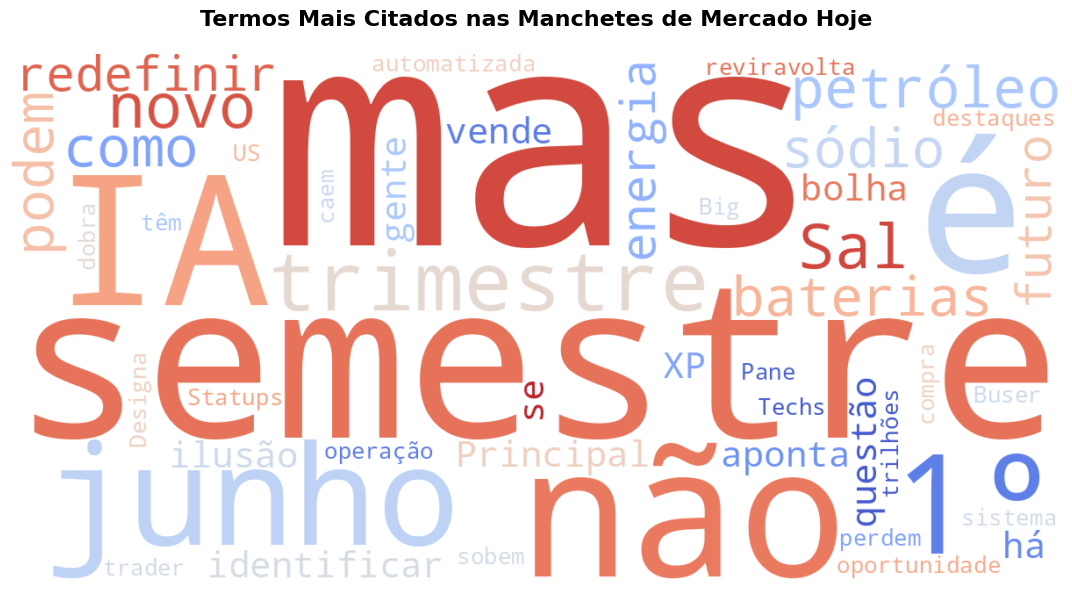

[VISUAL] Gráfico de Nuvem de Palavras gerado e salvo como 'nuvem_palavras_mercado.png'!


In [8]:
# ==============================================================================
# WEB SCRAPING E AUTOMAÇÃO DE DADOS ECONÔMICOS (COMPLETO + VISUAL)
# ==============================================================================

# 1. Instalação e Importação das Bibliotecas
!pip install requests beautifulsoup4 pandas wordcloud matplotlib --quiet

import requests
from bs4 import BeautifulSoup
import pandas as pd
from datetime import datetime
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# URL Alvo: Portal de mercados estável
url = "https://www.infomoney.com.br/mercados/"

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
}

print(f"Enviando requisição HTTP para: {url}...")
response = requests.get(url, headers=headers)

if response.status_code == 200:
    print("[SUCESSO] Página acessada. Iniciando parsing do HTML...")
    soup = BeautifulSoup(response.text, 'html.parser')

    # Lista para armazenar nossos dados raspados
    dados_noticias = []

    # Localizar os blocos de notícias (Baseado nas tags HTML do portal)
    artigos = soup.find_all(['h2', 'h3'], limit=15)

    for artigo in artigos:
        link_tag = artigo.find('a')
        if link_tag:
            titulo = link_tag.get_text(strip=True)
            link_completo = link_tag.get('href')

            # Limpeza e Tratamento do Texto (Data Cleaning)
            if len(titulo) > 10: # Filtra ruídos ou menus curtos do HTML
                dados_noticias.append({
                    "Data_Extracao": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
                    "Headline": titulo,
                    "Link": link_completo if link_completo.startswith('http') else f"https://www.infomoney.com.br{link_completo}"
                })

    # 2. Estruturação dos dados com Pandas
    df_noticias = pd.DataFrame(dados_noticias)

    # 3. Remover duplicadas e aplicar filtros textuais básicos
    df_noticias = df_noticias.drop_duplicates(subset=['Headline'])

    # Mostrar o resultado na tela
    print(f"\n[SUCESSO] Total de {len(df_noticias)} notícias únicas extraídas do mercado:")
    print(df_noticias.head(5))

    # 4. Exportação do Artefato CSV
    nome_arquivo = "noticias_mercado_bruto.csv"
    df_noticias.to_csv(nome_arquivo, index=False, encoding='utf-8-sig')
    print(f"\n[ARQUIVO GERADO] Dados exportados com sucesso para: '{nome_arquivo}'")

    # ==========================================================================
    # PARTE VISUAL: GERANDO ANÁLISE DE FREQUÊNCIA E WORDCLOUD DO MERCADO
    # ==========================================================================
    print("\nIniciando análise visual dos dados raspados...")

    # Consolidar todas as manchetes em um único bloco de texto
    texto_completo = " ".join(headline for headline in df_noticias['Headline'])

    # Configurar palavras que devem ser ignoradas (artigos, preposições, etc.)
    stopwords_pt = set(STOPWORDS)
    stopwords_pt.update([
        "de", "a", "o", "que", "e", "do", "da", "em", "um", "para", "com", "na", "no",
        "os", "as", "dos", "das", "mais", "por", "ao", "aos", "sobre", "pela",
        "pelo", "mercado", "ações", "bolsa", "ibovespa", "infomoney", "alta", "queda",
        "veja", "diz", "tem", "comprar", "vender", "por que"
    ])

    # Construir o objeto da Nuvem de Palavras
    nuvem = WordCloud(
        width=1200,
        height=600,
        background_color='white',
        stopwords=stopwords_pt,
        colormap='coolwarm',  # Paleta visual do projeto de terça-feira
        max_words=50
    ).generate(texto_completo)

    # Renderizar o gráfico
    plt.figure(figsize=(12, 6))
    plt.imshow(nuvem, interpolation='bilinear')
    plt.axis("off")  # Remove as bordas com eixos numéricos
    plt.title('Termos Mais Citados nas Manchetes de Mercado Hoje', fontsize=16, fontweight='bold', pad=20)
    plt.tight_layout()

    # Salvar a imagem final para alimentar o README do GitHub
    plt.savefig('nuvem_palavras_mercado.png', dpi=300)
    plt.show()

    print("[VISUAL] Gráfico de Nuvem de Palavras gerado e salvo como 'nuvem_palavras_mercado.png'!")

else:
    print(f"[ERRO] Falha ao acessar a página. Status Code: {response.status_code}")